# Lecture — Professional ML Pipelines (scikit-learn)

**Term:** Fall 2025  
**Week/Topic:** Pipelines for Preprocessing + Modeling  
**Instructor:** Dr. Bushaj

---

### Why this lecture
So far you've built **Linear Regression**, **Logistic Regression**, **kNN**, and **Classification/Regression Trees** with default or ad‑hoc parameters.  
Today we’ll make your code **professional**: reproducible, leakage‑free, and easy to tune & compare — using **`Pipeline`**, **`ColumnTransformer`**, and **`GridSearchCV`**.

### What you'll learn
- Build **end‑to‑end pipelines** that include imputation, encoding, scaling, optional PCA, and a model.
- Use **`GridSearchCV`** with namespaced parameters (e.g., `model__C`) to tune models **cleanly**.
- Compare **multiple algorithms** with a single, consistent framework.
- Produce a **model leaderboard**, pick the best model, and score **new data** safely.


## Imports

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_squared_error, r2_score
)

plt.rcParams["figure.figsize"] = (7.5, 5.0)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, linewidth=120)
pd.set_option("display.width", 120)

## 2. Checklist (applied to every model)

1. **Split first** (stratify for classification) — no peeking at validation/test.
2. **Preprocess with Pipelines** (impute, encode, scale, PCA) to avoid leakage.
3. **Tune with GridSearchCV** using `step__param` names.
4. **Cross-validate** with the right splitter (`StratifiedKFold` for classification).
5. **Compare** multiple pipelines fairly (same splits, same scoring).
6. **Save the whole pipeline** (it *is* the model), then use `.predict` on raw new data.

## Datasets (one for classification and another for regression)

In [ ]:
Xc, yc = make_classification(
    n_samples=800, n_features=12, n_informative=6, n_redundant=3,
    n_clusters_per_class=2, weights=None, flip_y=0.02, class_sep=1.2,
    random_state=42
)

Xc_train, Xc_valid, yc_train, yc_valid = train_test_split(
    Xc, yc, test_size=0.3, stratify=yc, random_state=26
)

Xr, yr = make_regression(
    n_samples=800, n_features=12, n_informative=8, noise=12.0, random_state=42
)

Xr_train, Xr_valid, yr_train, yr_valid = train_test_split(
    Xr, yr, test_size=0.3, random_state=26
)

print("Classification shapes:", Xc_train.shape, Xc_valid.shape)
print("Regression shapes:", Xr_train.shape, Xr_valid.shape)

Classification shapes: (560, 12) (240, 12)
Regression shapes: (560, 12) (240, 12)


## EDA - at the minimum, check distribution and correlation

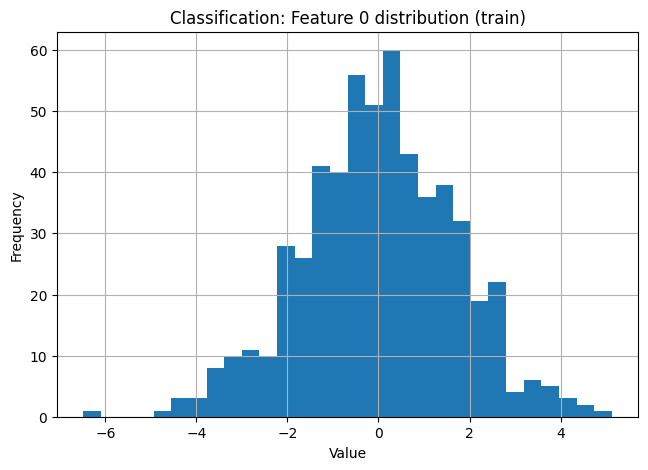

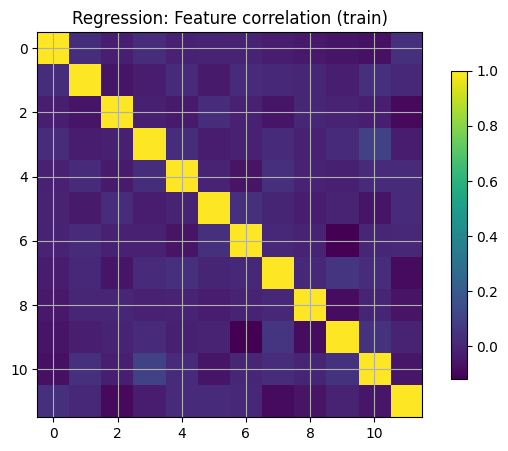

In [ ]:
fig, ax = plt.subplots()
ax.hist(Xc_train[:, 0], bins=30)
ax.set_title("Classification: Feature 0 distribution (train)")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
plt.show()

corr = np.corrcoef(Xr_train, rowvar=False)
plt.imshow(corr, interpolation="nearest")
plt.title("Regression: Feature correlation (train)")
plt.colorbar(shrink=0.8)
plt.show()

## Single Pipeline Example (Classification): Scaler → Logistic Regression

In [ ]:
clf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

clf_params = {
    "model__C": [0.1, 1, 10],
    "model__solver": ["lbfgs"],
    "model__penalty": ["l2"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=26)
grid_clf = GridSearchCV(clf_pipe, clf_params, cv=cv, scoring="accuracy", n_jobs=-1)
grid_clf.fit(Xc_train, yc_train)

print("Best params:", grid_clf.best_params_)
print("Best CV accuracy:", round(grid_clf.best_score_, 4))

yc_pred = grid_clf.predict(Xc_valid)
print("Validation accuracy:", round(accuracy_score(yc_valid, yc_pred), 4))
print("\nConfusion matrix (rows=true, cols=pred):\n", confusion_matrix(yc_valid, yc_pred))
print("\nClassification report:\n", classification_report(yc_valid, yc_pred))

Best params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV accuracy: 0.8268
Validation accuracy: 0.7875

Confusion matrix (rows=true, cols=pred):
 [[90 29]
 [22 99]]

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.76      0.78       119
           1       0.77      0.82      0.80       121

    accuracy                           0.79       240
   macro avg       0.79      0.79      0.79       240
weighted avg       0.79      0.79      0.79       240



## Multi-Model Comparison (Classification Example)

In [ ]:
clf_candidates = [
    (
        "LogisticRegression",
        Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
        {"model__C": [0.1, 1, 10]}
    ),
    (
        "kNN",
        Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier())]),
        {"model__n_neighbors": list(range(1, 16)), "model__weights": ["uniform", "distance"]}
    ),
    (
        "DecisionTree",
        Pipeline([("model", DecisionTreeClassifier(random_state=26))]),
        {"model__max_depth": [None, 3, 5, 8, 12], "model__min_samples_split": [2, 5, 10]}
    ),
    (
        "RandomForest",
        Pipeline([("model", RandomForestClassifier(random_state=26))]),
        {"model__n_estimators": [200, 400], "model__max_depth": [None, 6, 10]}
    ),
]

results = []
best_objects = {}

for name, pipe, grid in clf_candidates:
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="accuracy", n_jobs=-1)
    gs.fit(Xc_train, yc_train)
    valid_acc = accuracy_score(yc_valid, gs.predict(Xc_valid))
    results.append({
        "Model": name,
        "Best Params": gs.best_params_,
        "CV Mean Score": round(gs.best_score_, 4),
        "Valid Accuracy": round(valid_acc, 4)
    })
    best_objects[name] = gs.best_estimator_

leaderboard = pd.DataFrame(results).sort_values(by="Valid Accuracy", ascending=False).reset_index(drop=True)
display(leaderboard)

best_name = leaderboard.loc[0, "Model"]
best_clf = best_objects[best_name]
print("Winner:", best_name)
print(best_clf)

,Model,Best Params,CV Mean Score,Valid Accuracy
0,RandomForest,"{'model__max_depth': 10, 'model__n_estimators'...",0.9143,0.9042
1,kNN,"{'model__n_neighbors': 8, 'model__weights': 'd...",0.9089,0.8792
2,DecisionTree,"{'model__max_depth': 5, 'model__min_samples_sp...",0.8786,0.8667
3,LogisticRegression,{'model__C': 0.1},0.8268,0.7875


Winner: RandomForest
Pipeline(steps=[('model',
                 RandomForestClassifier(max_depth=10, n_estimators=400,
                                        random_state=26))])


## Multi-Model Comparison (Regression Example)

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=26)

reg_candidates = [
    (
        "LinearRegression",
        Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
        {}
    ),
    (
        "Ridge",
        Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
        {"model__alpha": [0.1, 1, 10, 50, 100]}
    ),
    (
        "Lasso",
        Pipeline([("scaler", StandardScaler()), ("model", Lasso(max_iter=5000))]),
        {"model__alpha": [0.001, 0.01, 0.1, 1, 10]}
    ),
    (
        "DecisionTreeRegressor",
        Pipeline([("model", DecisionTreeRegressor(random_state=26))]),
        {"model__max_depth": [None, 3, 5, 8, 12], "model__min_samples_split": [2, 5, 10]}
    ),
    (
        "RandomForestRegressor",
        Pipeline([("model", RandomForestRegressor(random_state=26))]),
        {"model__n_estimators": [200, 400], "model__max_depth": [None, 6, 10]}
    ),
]

reg_results = []
reg_best_objects = {}

for name, pipe, grid in reg_candidates:
    gs = GridSearchCV(pipe, grid, cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1)
    gs.fit(Xr_train, yr_train)
    pred = gs.predict(Xr_valid)
    rmse = np.sqrt(mean_squared_error(yr_valid, pred))
    r2 = r2_score(yr_valid, pred)
    reg_results.append({
        "Model": name,
        "Best Params": gs.best_params_,
        "CV Mean nRMSE": round(-gs.best_score_, 3),
        "Valid RMSE": round(rmse, 3),
        "Valid R2": round(r2, 4)
    })
    reg_best_objects[name] = gs.best_estimator_

display(pd.DataFrame(reg_results).sort_values(by="Valid RMSE"))

,Model,Best Params,CV Mean nRMSE,Valid RMSE,Valid R2
0,LinearRegression,{},11.854,11.020,0.9946
1,Ridge,{'model__alpha': 0.1},11.854,11.022,0.9946
2,Lasso,{'model__alpha': 0.1},11.835,11.057,0.9946
4,RandomForestRegressor,"{'model__max_depth': None, 'model__n_estimator...",75.965,75.917,0.7453
3,DecisionTreeRegressor,"{'model__max_depth': 8, 'model__min_samples_sp...",118.624,125.863,0.3000


## You could also add PCA into the pipeline (classification)

In [ ]:
pca_logit = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", LogisticRegression(max_iter=1000))
])

pca_grid = {
    "pca__n_components": [2, 3, 5, 8],
    "model__C": [0.1, 1, 10]
}

gs_pca = GridSearchCV(pca_logit, pca_grid, cv=cv, scoring="accuracy", n_jobs=-1)
gs_pca.fit(Xc_train, yc_train)

pca_valid_acc = accuracy_score(yc_valid, gs_pca.predict(Xc_valid))
print("PCA+Logit best params:", gs_pca.best_params_)
print("PCA+Logit CV mean acc:", round(gs_pca.best_score_, 4))
print("PCA+Logit valid acc:", round(pca_valid_acc, 4))

PCA+Logit best params: {'model__C': 10, 'pca__n_components': 8}
PCA+Logit CV mean acc: 0.8411
PCA+Logit valid acc: 0.8125


## Another good approach: helper methods

In [ ]:
# Core
import numpy as np
import pandas as pd

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, roc_curve, mean_squared_error
)

# Plotly (interactive)
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Display
pd.set_option("display.width", 120)


In [ ]:
def build_classification_registry():
    return {
        "LogReg": (
            Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
            {"model__C": [0.1, 1, 10]}
        ),
        "kNN": (
            Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier())]),
            {"model__n_neighbors": list(range(1, 16)), "model__weights": ["uniform", "distance"]}
        ),
        "Tree": (
            Pipeline([("model", DecisionTreeClassifier(random_state=26))]),
            {"model__max_depth": [None, 3, 5, 8], "model__min_samples_split": [2, 5, 10]}
        ),
        "Forest": (
            Pipeline([("model", RandomForestClassifier(random_state=26))]),
            {"model__n_estimators": [200, 400], "model__max_depth": [None, 6, 10]}
        ),
    }


In [ ]:
def evaluate_registry(X_train, y_train, X_valid, y_valid, registry, splitter, scoring="accuracy"):
    table, best_objs = [], {}
    for name, (pipe, grid) in registry.items():
        gs = GridSearchCV(pipe, grid, cv=splitter, scoring=scoring, n_jobs=-1)
        gs.fit(X_train, y_train)
        if scoring == "accuracy":
            score_valid = accuracy_score(y_valid, gs.predict(X_valid))
            table.append((name, gs.best_params_, round(gs.best_score_, 4), round(score_valid, 4)))
        else:
            preds = gs.predict(X_valid)
            rmse = np.sqrt(mean_squared_error(y_valid, preds))
            table.append((name, gs.best_params_, round(-gs.best_score_, 3), round(rmse, 3)))
        best_objs[name] = gs.best_estimator_
    df = pd.DataFrame(table, columns=[
        "Model", "Best Params", "CV Mean Score", "Valid Score"
    ])
    return df.sort_values(by="Valid Score", ascending=False).reset_index(drop=True), best_objs


In [ ]:
registry = build_classification_registry()
leaderboard2, best_objs2 = evaluate_registry(
    Xc_train, yc_train, Xc_valid, yc_valid, registry, cv, scoring="accuracy"
)

display(leaderboard2)
print("Top model object:", best_objs2[leaderboard2.loc[0, "Model"]])


,Model,Best Params,CV Mean Score,Valid Score
0,Forest,"{'model__max_depth': 10, 'model__n_estimators'...",0.9143,0.9042
1,kNN,"{'model__n_neighbors': 8, 'model__weights': 'd...",0.9089,0.8792
2,Tree,"{'model__max_depth': 5, 'model__min_samples_sp...",0.8786,0.8667
3,LogReg,{'model__C': 0.1},0.8268,0.7875


Top model object: Pipeline(steps=[('model',
                 RandomForestClassifier(max_depth=10, n_estimators=400,
                                        random_state=26))])


In [ ]:
def compute_classification_metrics(best_objs, X_valid, y_valid):
    """
    Compute common classification metrics for each fitted best pipeline.

    What we compute (and why):
      - Accuracy: overall correctness (fraction correct). Quick read; beware imbalance.
      - Precision: among predicted positives, how many are actually positive? (FP cost focus)
      - Recall: among actual positives, how many did we catch? (FN cost focus)
      - F1: harmonic mean of precision & recall; balances both.
      - ROC_AUC: threshold-independent ranking quality (binary default).
      - LogLoss: penalizes confident wrong predictions; lower is better (needs probabilities).

    Returns a DataFrame sorted by Accuracy (descending).
    """
    rows = []
    is_binary = len(np.unique(y_valid)) == 2
    avg = "binary" if is_binary else "macro"

    for name, est in best_objs.items():
        y_pred = est.predict(X_valid)

        acc = accuracy_score(y_valid, y_pred)
        prec = precision_score(y_valid, y_pred, average=avg, zero_division=0)
        rec  = recall_score(y_valid, y_pred, average=avg, zero_division=0)
        f1   = f1_score(y_valid, y_pred, average=avg, zero_division=0)

        auc = None
        ll  = None
        try:
            if hasattr(est, "predict_proba"):
                proba = est.predict_proba(X_valid)
                if is_binary:
                    auc = roc_auc_score(y_valid, proba[:, 1])
                ll = log_loss(y_valid, proba)
            elif hasattr(est, "decision_function"):
                dec = est.decision_function(X_valid)
                if is_binary:
                    auc = roc_auc_score(y_valid, dec)
        except Exception:
            pass

        rows.append({
            "Model": name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1": round(f1, 4),
            "ROC_AUC": None if auc is None else round(auc, 4),
            "LogLoss": None if ll is None else round(ll, 4),
        })

    return pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)


In [ ]:
def plot_leaderboard_bars_plotly(leaderboard_df, title="Model Leaderboard (CV vs Validation)"):
    """
    Grouped bars show CV Mean vs Validation scores per model.
    Interpretation:
      - Validation << CV can hint at overfitting or unstable CV.
      - Validation ≈ CV suggests good generalization.
    """
    df = leaderboard_df.copy()
    fig = go.Figure()
    fig.add_bar(x=df["Model"], y=df["CV Mean Score"], name="CV Mean")
    fig.add_bar(x=df["Model"], y=df["Valid Score"], name="Validation")

    fig.update_layout(
        barmode="group",
        title=title,
        xaxis_title="Model",
        yaxis_title="Score",
        yaxis=dict(range=[0, 1]),
        legend_title="Metric",
        bargap=0.25
    )
    fig.show()


In [ ]:
def plot_confusion_matrices_plotly(best_objs, X_valid, y_valid, model_names, cols=2, normalize="true"):
    """
    Plot confusion matrices (as Plotly heatmaps) for selected models.

    normalize options:
      - "true": row-normalized (each true class sums to 1) -> read as recall per class
      - None: raw counts
    Why useful:
      - Reveals *type* of errors (FP vs FN) per class; crucial for imbalanced tasks.
    """
    import math
    n = len(model_names)
    rows = math.ceil(n / cols)

    # Precompute axes titles
    classes = np.unique(y_valid)
    xt = [f"Pred {c}" for c in classes]
    yt = [f"True {c}" for c in classes]

    fig = make_subplots(rows=rows, cols=cols, subplot_titles=model_names)

    for i, name in enumerate(model_names):
        r, c = divmod(i, cols)
        r, c = r + 1, c + 1
        est = best_objs[name]
        y_pred = est.predict(X_valid)
        cm = confusion_matrix(y_valid, y_pred)

        if normalize == "true":
            with np.errstate(all='ignore'):
                z = cm / cm.sum(axis=1, keepdims=True)
        else:
            z = cm

        # Use raw counts as text overlay; z drives colors
        fig.add_trace(
            go.Heatmap(
                z=z,
                x=xt, y=yt,
                text=cm, texttemplate="%{text}",
                coloraxis="coloraxis",
                showscale=False
            ),
            row=r, col=c
        )

    fig.update_layout(
        coloraxis=dict(colorscale="Viridis"),
        title="Confusion Matrices",
        height=300 * rows
    )
    fig.show()


In [ ]:
def plot_roc_curves_plotly(best_objs, X_valid, y_valid, model_names=None):
    """
    ROC curves (binary):
      - Threshold-independent view of ranking quality.
      - AUC summarizes the whole curve (higher=better).
    Uses predict_proba if available; else decision_function.
    """
    classes = np.unique(y_valid)
    if len(classes) != 2:
        print("ROC curves shown only for binary classification.")
        return

    if model_names is None:
        model_names = list(best_objs.keys())

    fig = go.Figure()
    any_ok = False

    for name in model_names:
        est = best_objs[name]
        try:
            if hasattr(est, "predict_proba"):
                scores = est.predict_proba(X_valid)[:, 1]
            elif hasattr(est, "decision_function"):
                scores = est.decision_function(X_valid)
            else:
                continue

            fpr, tpr, _ = roc_curve(y_valid, scores)
            auc = roc_auc_score(y_valid, scores)
            fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"{name} (AUC={auc:.3f})"))
            any_ok = True
        except Exception:
            pass

    if not any_ok:
        print("No models provided probability/decision scores; cannot plot ROC.")
        return

    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", name="Random", line=dict(dash="dash")))
    fig.update_layout(
        title="ROC Curves (Validation)",
        xaxis_title="False Positive Rate",
        yaxis_title="True Positive Rate"
    )
    fig.show()


In [ ]:
def compare_all_plotly(leaderboard_df, best_objs, X_valid, y_valid, topk=3, title_suffix=""):
    """
    Convenience:
      1) Grouped bars (CV vs Validation)
      2) Validation metrics table (Accuracy/Precision/Recall/F1/ROC_AUC/LogLoss)
      3) Confusion matrices for top-k models
      4) ROC curves (binary only)
    """
    # (1) Bars
    plot_leaderboard_bars_plotly(leaderboard_df, title=f"Model Leaderboard {title_suffix}".strip())

    # (2) Table of metrics
    metrics_df = compute_classification_metrics(best_objs, X_valid, y_valid)
    fig_table = go.Figure(
        data=[go.Table(
            header=dict(values=list(metrics_df.columns)),
            cells=dict(values=[metrics_df[c] for c in metrics_df.columns])
        )]
    )
    fig_table.update_layout(title="Validation Metrics by Model")
    fig_table.show()

    # (3) Confusion matrices
    top_models = leaderboard_df["Model"].head(topk).tolist()
    plot_confusion_matrices_plotly(best_objs, X_valid, y_valid, top_models, cols=min(topk, 3), normalize="true")

    # (4) ROC (binary only)
    plot_roc_curves_plotly(best_objs, X_valid, y_valid, leaderboard_df["Model"].tolist())


In [ ]:
# Detailed metrics table
metrics_table = compute_classification_metrics(best_objs2, Xc_valid, yc_valid)
display(metrics_table)

# Grouped bars: CV vs Validation
plot_leaderboard_bars_plotly(leaderboard2)

# Confusion matrices for top-3 models (row-normalized with raw counts displayed)
top3 = leaderboard2["Model"].head(3).tolist()
plot_confusion_matrices_plotly(best_objs2, Xc_valid, yc_valid, top3, cols=3, normalize="true")

# ROC curves (only if binary)
plot_roc_curves_plotly(best_objs2, Xc_valid, yc_valid, leaderboard2["Model"].tolist())

# Or run everything in one call:
compare_all_plotly(leaderboard2, best_objs2, Xc_valid, yc_valid, topk=3, title_suffix="(CV vs Validation)")


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,Forest,0.9042,0.9153,0.8926,0.9038,0.9569,0.2846
1,kNN,0.8792,0.8966,0.8595,0.8776,0.9500,0.5580
2,Tree,0.8667,0.8739,0.8595,0.8667,0.9036,0.8092
3,LogReg,0.7875,0.7734,0.8182,0.7952,0.8949,0.4127


## We can Save & Load the whole pipeline

In [ ]:
import joblib

best_model_name = leaderboard2.loc[0, "Model"]
best_pipeline = best_objs2[best_model_name]

joblib.dump(best_pipeline, "best_pipeline.pkl")
print("Saved:", "best_pipeline.pkl")

loaded = joblib.load("best_pipeline.pkl")
sample = Xc_valid[:5]
print("Loaded pipeline prediction (first 5):", loaded.predict(sample))

Saved: best_pipeline.pkl
Loaded pipeline prediction (first 5): [0 1 0 1 1]


## What did we change on our strategy???

- **Wrap everything in a Pipeline**: imputation, encoding, scaling, PCA, and the estimator.
- **No data leakage**: all preprocessing learned **only** from training folds.
- **Consistent tuning** with `GridSearchCV` using namespaced params (e.g., `model__C`).
- **One framework, many models**: swap estimators without rewriting preprocessing.
- **Leaderboard mindset**: compare CV and validation metrics, then freeze the winner.
- **Ship the pipeline**: save the *entire* pipeline; it becomes your production model.